In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
class Value:

    def __init__(self, data, _children=(), _op = "", label = ""):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None # by default, it won't do anything
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data: {self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), "+")

        def _backward():
            self.grad = 1.0 * out.grad
            other.grad = 1.0 * out.grad
        out._backward = _backward
        # be caution! Here, the value is '_backward' and not '_backward()'

        return out
    # __add__ is a function of class. When write a + b, py will run a.__add__(b)

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), "*")

        def _backward():
            self.grad = other.data * out.grad
            other.grad = self.data * out.grad
        out._backward = _backward

        return out
    # just like the __add__ function

    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1) / (math.exp(2*x)+1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad = (1 - t**2) * out.grad
        out._backward = _backward

        return out

In [3]:
a = Value(2.0, label="a")
b = Value(3.0, label="b")
c = Value(4.0, label="c")

a, b

(Value(data: 2.0), Value(data: 3.0))

In [4]:
a + b

Value(data: 5.0)

In [5]:
e = a*b; e.label = "e"
d = e + c; d.label = "d"
d, d._prev, d._op

(Value(data: 10.0), {Value(data: 4.0), Value(data: 6.0)}, '+')

In [6]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format="svg", graph_attr={"rankdir": "LR"}) # LR = left to right

    nodes, edges = trace(root)
    for node in nodes:
        uid = str(id(node))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" %
                    (node.label, node.data, node.grad),
                        shape="record")
        if node._op:
            # if this value is a result of same operation, crate an op node for it
            dot.node(name = uid + node._op, label = node._op )
            # and connect this node to it
            dot.edge(uid + node._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot


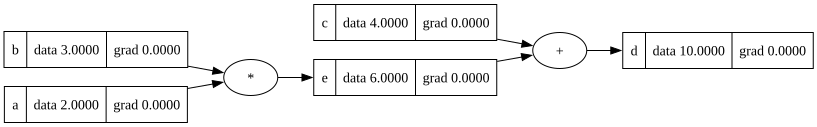

In [7]:
draw_dot(d)

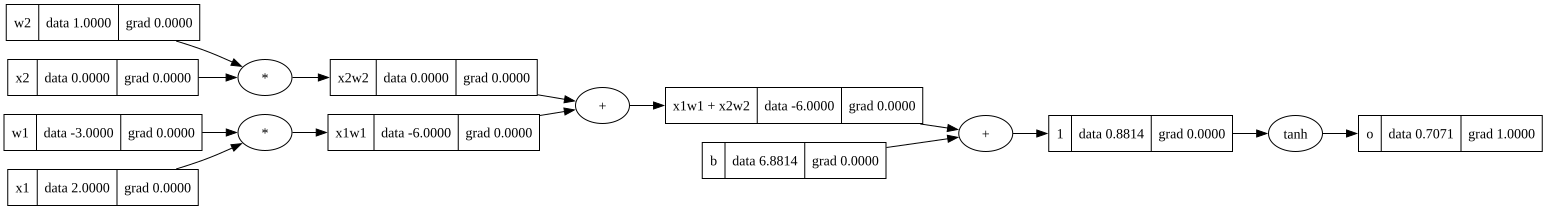

In [16]:
# input x1 and x2
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
# weight w1 and w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
# bias of the neuron
b = Value(6.8813735870195432, label = 'b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = '1'
o = n.tanh(); o.label = 'o'
o.grad = 1.0
draw_dot(o)

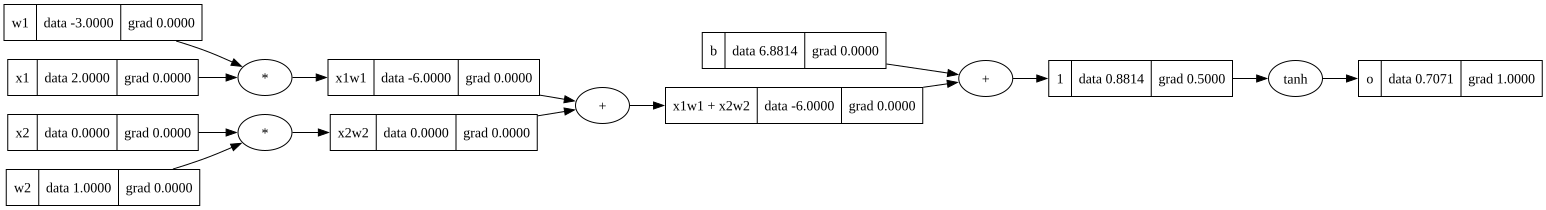

In [9]:
o._backward()
draw_dot(o)

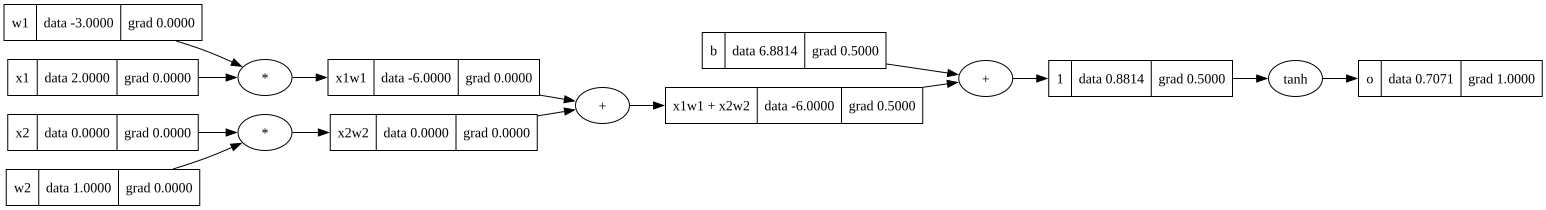

In [10]:
n._backward()
draw_dot(o)

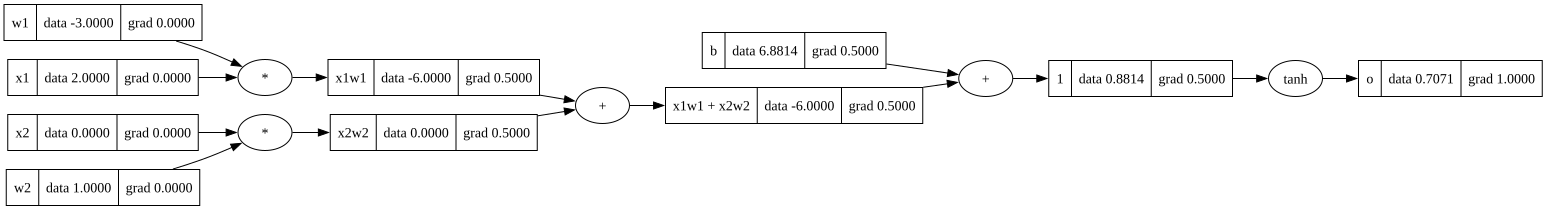

In [11]:
b._backward()
x1w1x2w2._backward()
draw_dot(o)

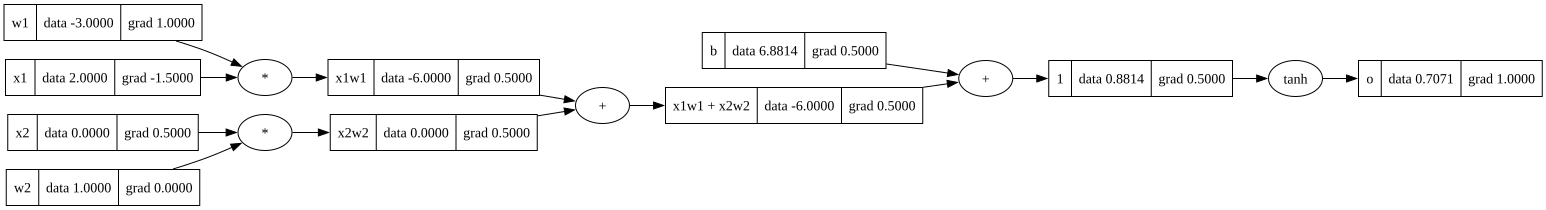

In [12]:
x1w1._backward()
x2w2._backward()
draw_dot(o)

In [17]:
# Or we can build the topo graph to avoid code every node's _backward function manuscriptally
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
visited

{Value(data: -3.0),
 Value(data: -6.0),
 Value(data: -6.0),
 Value(data: 0.0),
 Value(data: 0.0),
 Value(data: 0.7071067811865476),
 Value(data: 0.8813735870195432),
 Value(data: 1.0),
 Value(data: 2.0),
 Value(data: 6.881373587019543)}

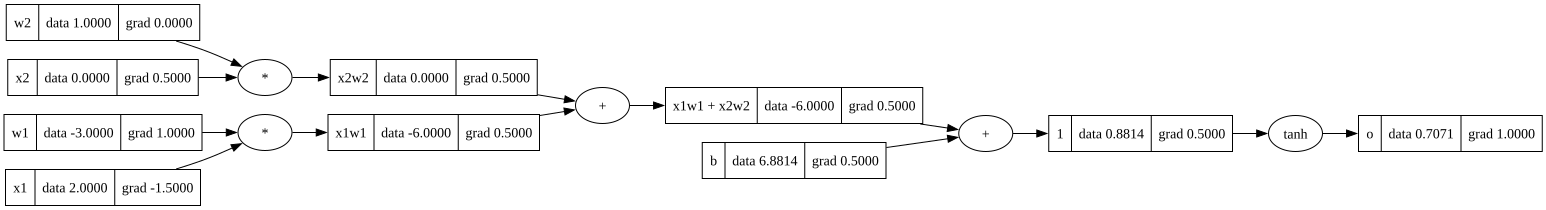

In [18]:
for node in reversed(topo):
    node._backward()
draw_dot(o)

**我们必须在计算完此节点往后的梯度时才可以调用_backward()来计算此节点关联的子节点的梯度**

In [19]:
# the final Value class (pay attention to one fine change here)
class Value:

    def __init__(self, data, _children=(), _op = "", label = ""):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data: {self.data})"

    # a + b
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        # to avoid the error of a+1
        out = Value(self.data + other.data, (self, other), "+")

        def _backward():
            self.grad += 1.0 * out.grad # (important!!!) We shouldn't overwrite the former gradients, so we should accumulate these gradients
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out

    # a * b
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        # to avoid the error of a*2
        out = Value(self.data * other.data, (self, other), "*")

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out

    def __rmul__(self, other): # to solve the problem like 2*a(other*self)
        return self * other

    # a / b
    def __truediv__(self, other): # self / other
        other = other if isinstance(other, Value) else Value(other)
        return self * other**-1

    # negative
    def __neg__(self): # -self
        return self * -1

    # a - b
    def __sub__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return self + (-other)
    
    # x**K
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only suporting int/float powers for now!!!"
        out = Value(self.data**other, (self, ), f"**{other}")

        def _backward():
            self.grad += out.grad * (other.data*self.data**(other.data-1))
        out._backward = _backward

        return out

    # tanh
    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1) / (math.exp(2*x)+1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward

        return out

    # exp
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out

    def backward(self):
        # we build the overall backward function
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()


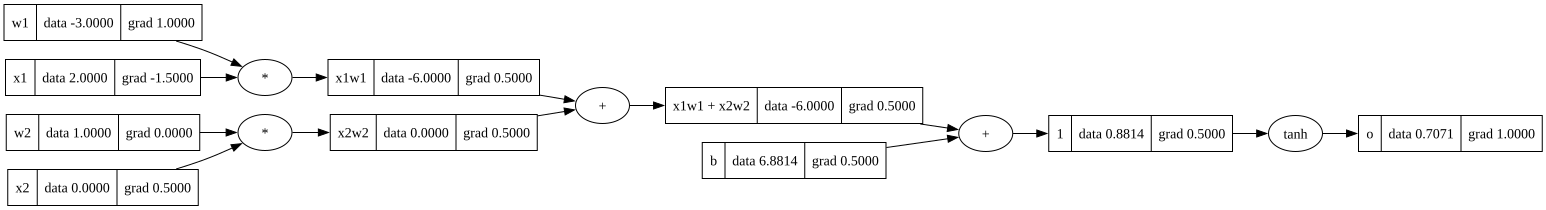

In [20]:
# try again!

# input x1 and x2
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
# weight w1 and w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
# bias of the neuron
b = Value(6.8813735870195432, label = 'b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = '1'
o = n.tanh(); o.label = 'o'
o.backward()
draw_dot(o)

In [1]:
import torch
x1 = torch.tensor([2.0]).double();              x1.requires_grad = True
x2 = torch.tensor([0.0]).double();              x2.requires_grad = True
w1 = torch.tensor([-3.0]).double();             w1.requires_grad = True
w2 = torch.tensor([1.0]).double();              w2.requires_grad = True
b = torch.tensor([6.8813735870195432]).double();b.requires_grad = True

h = x1 * w1 + x2 * w2 + b
o = torch.tanh(h)

print(o.data.item())
o.backward()

print('==========')
print('x1:', x1.grad.item())
print('x2:', x2.grad.item())
print('w1:', w1.grad.item())
print('w2:', w2.grad.item())
# the item() function is used to extract the data from the pytorch tensor as a single numble

0.7071066904050358
x1: -1.5000003851533106
x2: 0.5000001283844369
w1: 1.0000002567688737
w2: 0.0
